# Importación de Librerías para Descarga de Pizzerías

In [15]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import os
import numpy as np
import time

# Configuración
ox.settings.timeout = 1800  # 30 minutos por provincia (sobra)
ox.settings.requests_per_second = 1
ox.settings.memory = 8192
ox.settings.log_console = True

# Tags (igual que antes)
tags = {'amenity': ['restaurant', 'pizza'], 'cuisine': 'pizza'}

# Lista de provincias (52) - Formato OSMnx
provincias = [
    "Albacete, Spain", "Alicante, Spain", "Almería, Spain", 
    "Araba/Álava, Spain", "Asturias, Spain", "Ávila, Spain",
    "Badajoz, Spain", "Baleares, Spain", "Barcelona, Spain",
    "Burgos, Spain", "Cáceres, Spain", "Cádiz, Spain",
    "Cantabria, Spain", "Castellón, Spain", "Ciudad Real, Spain",
    "Córdoba, Spain", "A Coruña, Spain", "Cuenca, Spain",
    "Girona, Spain", "Granada, Spain", "Guadalajara, Spain",
    "Gipuzkoa, Spain", "Huelva, Spain", "Huesca, Spain",
    "Jaén, Spain", "León, Spain", "Lleida, Spain",
    "Lugo, Spain", "Madrid, Spain", "Málaga, Spain",
    "Murcia, Spain", "Navarra, Spain", "Ourense, Spain",
    "Palencia, Spain", "Las Palmas, Spain", "Pontevedra, Spain",
    "La Rioja, Spain", "Salamanca, Spain", "Santa Cruz de Tenerife, Spain",
    "Segovia, Spain", "Sevilla, Spain", "Soria, Spain",
    "Tarragona, Spain", "Teruel, Spain", "Toledo, Spain",
    "Valencia, Spain", "Valladolid, Spain", "Bizkaia, Spain",
    "Zamora, Spain", "Zaragoza, Spain", "Ceuta, Spain", "Melilla, Spain"
]

# Crear carpeta de salida
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

print("🔥 Iniciando descarga de pizzerías POR PROVINCIAS...")
print(f"📊 Total: {len(provincias)} provincias")
print("⏱️  Cada provincia tomará ~20-30 segundos (como Madrid)")
print("🎯 Tiempo estimado total: 20-30 minutos")

# Lista para guardar todos los resultados
gdfs = []
resultados = {}

# Iterar por provincias
for i, provincia in enumerate(provincias, 1):
    print(f"\n{'='*50}")
    print(f"📥 {i}/{len(provincias)}: {provincia}")
    start_time = time.time()
    
    try:
        # Descargar datos de la provincia
        gdf = ox.features_from_place(provincia, tags)
        elapsed = time.time() - start_time
        
        # Guardar en lista
        gdfs.append(gdf)
        resultados[provincia] = len(gdf)
        
        print(f"   ✅ {len(gdf)} pizzerías en {elapsed:.1f} segundos")
        
        # Guardar respaldo cada 10 provincias
        if i % 10 == 0:
            temp_gdf = pd.concat(gdfs, ignore_index=True)
            temp_file = os.path.join(output_dir, f"respaldo_provincias_{i}.gpkg")
            temp_gdf.to_file(temp_file, driver="GPKG")
            print(f"   💾 Respaldo guardado: {temp_file}")
            
    except Exception as e:
        elapsed = time.time() - start_time
        print(f"   ❌ Error después de {elapsed:.1f} segundos: {e}")
        resultados[provincia] = "ERROR"
        continue

# Si todo salió bien, unir todos los resultados
if gdfs:
    print("\n" + "="*50)
    print("📊 Uniendo todas las provincias...")
    gdf_total = pd.concat(gdfs, ignore_index=True)
    
    # Limpiar columnas (como antes)
    cols_interes = ['name', 'geometry', 'opening_hours', 'phone', 'website', 'brand', 'brand:wikidata']
    gdf_clean = gdf_total[[c for c in cols_interes if c in gdf_total.columns]].copy()
    
    # Añadir metadatos
    gdf_clean['pais'] = 'España'
    gdf_clean['fecha_descarga'] = pd.Timestamp.now()
    
    # Guardar GeoPackage completo
    output_file = os.path.join(output_dir, "pizzerias_osm_spain_completo.gpkg")
    gdf_clean.to_file(output_file, driver="GPKG")
    print(f"📁 GeoPackage guardado en: {output_file}")
    
    # Extraer coordenadas (igual que antes)
    def extraer_coordenadas(geom):
        if geom is None:
            return np.nan, np.nan
        elif geom.geom_type == 'Point':
            return geom.x, geom.y
        elif geom.geom_type in ['Polygon', 'MultiPolygon']:
            centroide = geom.centroid
            return centroide.x, centroide.y
        elif geom.geom_type in ['LineString', 'MultiLineString']:
            return geom.interpolate(0.5, normalized=True).x, geom.interpolate(0.5, normalized=True).y
        else:
            return np.nan, np.nan
    
    gdf_clean['coords'] = gdf_clean.geometry.apply(extraer_coordenadas)
    gdf_clean['lon'] = gdf_clean['coords'].apply(lambda x: x[0])
    gdf_clean['lat'] = gdf_clean['coords'].apply(lambda x: x[1])
    gdf_clean = gdf_clean.drop(columns=['coords'])
    
    # Añadir tipo de geometría
    gdf_clean['tipo_geometria'] = gdf_clean.geometry.geom_type
    
    # Guardar CSV
    csv_file = os.path.join(output_dir, "pizzerias_osm_spain_con_coordenadas.csv")
    gdf_clean[['name', 'lon', 'lat', 'tipo_geometria', 'pais', 'fecha_descarga']].to_csv(csv_file, index=False)
    print(f"📊 CSV guardado con {len(gdf_clean)} elementos en: {csv_file}")
    
    # Estadísticas finales
    print("\n📊 RESUMEN FINAL:")
    print(f"Total pizzerías en España: {len(gdf_clean)}")
    print("\nPor tipo de geometría:")
    print(gdf_clean['tipo_geometria'].value_counts())
    
    print("\n📊 Por provincia (exitosas):")
    for prov, count in resultados.items():
        if count != "ERROR":
            print(f"  • {prov}: {count}")
    
    print("\n🎉 ¡PROCESO COMPLETADO CON ÉXITO!")
else:
    print("\n❌ No se pudo descargar ninguna provincia.")

🔥 Iniciando descarga de pizzerías POR PROVINCIAS...
📊 Total: 52 provincias
⏱️  Cada provincia tomará ~20-30 segundos (como Madrid)
🎯 Tiempo estimado total: 20-30 minutos

📥 1/52: Albacete, Spain
   ✅ 154 pizzerías en 5.1 segundos

📥 2/52: Alicante, Spain
   ✅ 449 pizzerías en 5.0 segundos

📥 3/52: Almería, Spain
   ✅ 212 pizzerías en 28.0 segundos

📥 4/52: Araba/Álava, Spain
   ✅ 402 pizzerías en 86.3 segundos

📥 5/52: Asturias, Spain
   ✅ 1884 pizzerías en 169.5 segundos

📥 6/52: Ávila, Spain
   ✅ 65 pizzerías en 9.8 segundos

📥 7/52: Badajoz, Spain
   ✅ 94 pizzerías en 22.8 segundos

📥 8/52: Baleares, Spain
   ✅ 3523 pizzerías en 480.9 segundos

📥 9/52: Barcelona, Spain
   ✅ 3795 pizzerías en 5.5 segundos

📥 10/52: Burgos, Spain
   ✅ 281 pizzerías en 8.9 segundos
   💾 Respaldo guardado: ../data/raw/respaldo_provincias_10.gpkg

📥 11/52: Cáceres, Spain
   ✅ 108 pizzerías en 37.5 segundos

📥 12/52: Cádiz, Spain
   ✅ 186 pizzerías en 3.0 segundos

📥 13/52: Cantabria, Spain
   ✅ 1180 pizz

In [16]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import os
import numpy as np

# Configuración
ox.settings.timeout = 1800
ox.settings.requests_per_second = 1
ox.settings.memory = 8192
ox.settings.log_console = True

tags = {'amenity': ['restaurant', 'pizza'], 'cuisine': 'pizza'}

# Provincias que fallaron
provincias_faltantes = [
    "Palencia, Spain",
    "Las Palmas, Spain",
    "Pontevedra, Spain",
    "La Rioja, Spain",
    "Salamanca, Spain",
    "Santa Cruz de Tenerife, Spain",
    "Segovia, Spain"
]

output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

print("🔥 Descargando provincias faltantes...")
print(f"📊 Total: {len(provincias_faltantes)} provincias")

# Cargar el dataset existente
archivo_completo = os.path.join(output_dir, "pizzerias_osm_spain_completo.gpkg")
gdf_existente = gpd.read_file(archivo_completo)
print(f"📊 Dataset actual: {len(gdf_existente)} elementos")

# Lista para guardar nuevas provincias
nuevos_gdfs = []

for i, provincia in enumerate(provincias_faltantes, 1):
    print(f"\n{'='*50}")
    print(f"📥 {i}/{len(provincias_faltantes)}: {provincia}")
    
    try:
        gdf = ox.features_from_place(provincia, tags)
        nuevos_gdfs.append(gdf)
        print(f"   ✅ {len(gdf)} pizzerías")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        continue

# Si se descargaron nuevas provincias
if nuevos_gdfs:
    # Unir nuevas provincias
    gdf_nuevas = pd.concat(nuevos_gdfs, ignore_index=True)
    
    # Unir con dataset existente
    gdf_total = pd.concat([gdf_existente, gdf_nuevas], ignore_index=True)
    
    # Limpiar columnas (igual que antes)
    cols_interes = ['name', 'geometry', 'opening_hours', 'phone', 'website', 'brand', 'brand:wikidata']
    gdf_clean = gdf_total[[c for c in cols_interes if c in gdf_total.columns]].copy()
    
    # Añadir metadatos
    gdf_clean['pais'] = 'España'
    gdf_clean['fecha_descarga'] = pd.Timestamp.now()
    
    # Guardar GeoPackage actualizado
    output_file = os.path.join(output_dir, "pizzerias_osm_spain_completo_actualizado.gpkg")
    gdf_clean.to_file(output_file, driver="GPKG")
    print(f"\n📁 GeoPackage actualizado guardado en: {output_file}")
    
    # Extraer coordenadas
    def extraer_coordenadas(geom):
        if geom is None:
            return np.nan, np.nan
        elif geom.geom_type == 'Point':
            return geom.x, geom.y
        elif geom.geom_type in ['Polygon', 'MultiPolygon']:
            centroide = geom.centroid
            return centroide.x, centroide.y
        elif geom.geom_type in ['LineString', 'MultiLineString']:
            return geom.interpolate(0.5, normalized=True).x, geom.interpolate(0.5, normalized=True).y
        else:
            return np.nan, np.nan
    
    gdf_clean['coords'] = gdf_clean.geometry.apply(extraer_coordenadas)
    gdf_clean['lon'] = gdf_clean['coords'].apply(lambda x: x[0])
    gdf_clean['lat'] = gdf_clean['coords'].apply(lambda x: x[1])
    gdf_clean = gdf_clean.drop(columns=['coords'])
    
    # Añadir tipo de geometría
    gdf_clean['tipo_geometria'] = gdf_clean.geometry.geom_type
    
    # Guardar CSV actualizado
    csv_file = os.path.join(output_dir, "pizzerias_osm_spain_con_coordenadas_actualizado.csv")
    gdf_clean[['name', 'lon', 'lat', 'tipo_geometria', 'pais', 'fecha_descarga']].to_csv(csv_file, index=False)
    print(f"📊 CSV actualizado guardado con {len(gdf_clean)} elementos en: {csv_file}")
    
    # Estadísticas finales
    print(f"\n📊 RESUMEN FINAL:")
    print(f"Total pizzerías en España: {len(gdf_clean)}")
    print(f"  • Antes: {len(gdf_existente)}")
    print(f"  • Nuevas: {len(gdf_nuevas)}")
    
    # Mostrar nuevas provincias
    print("\n📊 Nuevas provincias añadidas:")
    for gdf in nuevos_gdfs:
        if len(gdf) > 0:
            # Intentar obtener provincia del primer elemento
            prov = gdf.iloc[0].get('provincia', 'Desconocida')
            print(f"  • {len(gdf)} pizzerías")

else:
    print("\n❌ No se pudo descargar ninguna provincia nueva.")

🔥 Descargando provincias faltantes...
📊 Total: 7 provincias
📊 Dataset actual: 31368 elementos

📥 1/7: Palencia, Spain
   ✅ 240 pizzerías

📥 2/7: Las Palmas, Spain
   ✅ 508 pizzerías

📥 3/7: Pontevedra, Spain
   ✅ 94 pizzerías

📥 4/7: La Rioja, Spain
   ✅ 293 pizzerías

📥 5/7: Salamanca, Spain
   ✅ 205 pizzerías

📥 6/7: Santa Cruz de Tenerife, Spain
   ✅ 246 pizzerías

📥 7/7: Segovia, Spain
   ✅ 92 pizzerías

📁 GeoPackage actualizado guardado en: ../data/raw/pizzerias_osm_spain_completo_actualizado.gpkg
📊 CSV actualizado guardado con 33046 elementos en: ../data/raw/pizzerias_osm_spain_con_coordenadas_actualizado.csv

📊 RESUMEN FINAL:
Total pizzerías en España: 33046
  • Antes: 31368
  • Nuevas: 1678

📊 Nuevas provincias añadidas:
  • 240 pizzerías
  • 508 pizzerías
  • 94 pizzerías
  • 293 pizzerías
  • 205 pizzerías
  • 246 pizzerías
  • 92 pizzerías


# Importación de Librerías para Análisis de Archivos INE

In [18]:
import pandas as pd

# Ruta al archivo
archivo = "../data/raw/pobmun/pobmun25.xlsx"

# Leer Excel (puede tener varias pestañas)
xls = pd.ExcelFile(archivo)
print("Hojas disponibles:", xls.sheet_names)

# Leer la hoja principal (suele ser la primera)
df = pd.read_excel(archivo, sheet_name=0)

# Ver primeras filas
print("\nPrimeras filas:")
print(df.head())

# Ver información general
print("\nInformación del DataFrame:")
print(df.info())

# Ver columnas disponibles
print("\nColumnas:", df.columns.tolist())

Hojas disponibles: ['dic25']

Primeras filas:
  Cifras de población resultantes de la Revisión del Padrón municipal a 1 de enero de 2025  \
0                                               CPRO                                         
1                                                 01                                         
2                                                 01                                         
3                                                 01                                         
4                                                 01                                         

    Unnamed: 1 Unnamed: 2        Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  
0    PROVINCIA       CMUN            NOMBRE      POB25    HOMBRES    MUJERES  
1  Araba/Álava        001  Alegría-Dulantzi       2955       1522       1433  
2  Araba/Álava        002           Amurrio      10364       5133       5231  
3  Araba/Álava        003           Aramaio       1354        687        

# Limpieza del Excel

In [19]:
# Ruta al archivo
archivo = "../data/raw/pobmun/pobmun25.xlsx"

# Leer el Excel saltando las primeras filas innecesarias
df_raw = pd.read_excel(archivo, sheet_name='dic25', header=1)

# Ver resultado
print("Primeras filas después de limpiar:")
print(df_raw.head())

# Ver información
print("\nInformación del DataFrame:")
print(df_raw.info())

Primeras filas después de limpiar:
   CPRO    PROVINCIA  CMUN            NOMBRE  POB25  HOMBRES  MUJERES
0     1  Araba/Álava     1  Alegría-Dulantzi   2955     1522     1433
1     1  Araba/Álava     2           Amurrio  10364     5133     5231
2     1  Araba/Álava     3           Aramaio   1354      687      667
3     1  Araba/Álava     4        Artziniega   1868      923      945
4     1  Araba/Álava     6           Armiñón    236      124      112

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CPRO       8132 non-null   int64 
 1   PROVINCIA  8132 non-null   object
 2   CMUN       8132 non-null   int64 
 3   NOMBRE     8132 non-null   object
 4   POB25      8132 non-null   int64 
 5   HOMBRES    8132 non-null   int64 
 6   MUJERES    8132 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 444.8+ KB
None


In [20]:
# Guardar CSV limpio para uso futuro
output_file = "../data/processed/poblacion_municipios_2025_limpio.csv"
df_raw.to_csv(output_file, index=False, encoding='utf-8')
print(f"✅ Archivo limpio guardado en: {output_file}")

# Verificar que se guardó
print("\nArchivos en data/processed:")
print(os.listdir("../data/processed"))

✅ Archivo limpio guardado en: ../data/processed/poblacion_municipios_2025_limpio.csv

Archivos en data/processed:
['poblacion_municipios_2025_limpio.csv']


In [21]:
# Leer el archivo guardado para confirmar
df_check = pd.read_csv("../data/processed/poblacion_municipios_2025_limpio.csv")
print("\nPrimeras filas del archivo guardado:")
print(df_check.head())
print(f"\nShape: {df_check.shape}")


Primeras filas del archivo guardado:
   CPRO    PROVINCIA  CMUN            NOMBRE  POB25  HOMBRES  MUJERES
0     1  Araba/Álava     1  Alegría-Dulantzi   2955     1522     1433
1     1  Araba/Álava     2           Amurrio  10364     5133     5231
2     1  Araba/Álava     3           Aramaio   1354      687      667
3     1  Araba/Álava     4        Artziniega   1868      923      945
4     1  Araba/Álava     6           Armiñón    236      124      112

Shape: (8132, 7)


# Unión de Pizzerías con Población

In [23]:
import unicodedata

# 1. Cargar datos
print("Cargando datos...")
pizzeria_df = pd.read_csv("../data/raw/pizzerias_osm_spain_con_coordenadas.csv")
poblacion_df = pd.read_csv("../data/processed/poblacion_municipios_2025_limpio.csv")

# 2. Crear GeoDataFrame de pizzerías
gdf_pizzeria = gpd.GeoDataFrame(
    pizzeria_df, 
    geometry=gpd.points_from_xy(pizzeria_df.lon, pizzeria_df.lat),
    crs="EPSG:4326"
)

# 3. Normalizar nombres para unión aproximada (útil para depuración, aunque usaremos provincia)
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto

# Aplicar normalización a los nombres de municipio en ambos dataframes
poblacion_df['nombre_norm'] = poblacion_df['NOMBRE'].apply(normalizar_texto)
gdf_pizzeria['nombre_municipio_norm'] = gdf_pizzeria['name'].apply(lambda x: normalizar_texto(x) if pd.notna(x) else '')

print("\n--- ANÁLISIS POR PROVINCIA ---")

# 4. Agrupar pizzerías por provincia
# Nota: Usamos la columna 'PROVINCIA' de población como base. Primero, extraemos el nombre de provincia del df de población.
provincias_ine = poblacion_df[['PROVINCIA']].drop_duplicates().copy()
# Normalizamos el nombre de la provincia en los datos de pizzerías (columna 'pais' no sirve, necesitamos la provincia).
# Como no tenemos la provincia directamente en pizzeria_df, haremos una asignación aproximada.
# Solución pragmática: Extraer provincia de 'name' o confiar en que más adelante la unión espacial lo resolverá.
# Por ahora, calculamos el total nacional y dejamos el desglose provincial para el cruce espacial real.

# Calcular total de pizzerías
total_pizzerias = len(gdf_pizzeria)
print(f"Total de pizzerías en España: {total_pizzerias}")

# Calcular población total
poblacion_total = poblacion_df['POB25'].sum()
print(f"Población total (2025): {poblacion_total:,}")

# Calcular ratio nacional
ratio_nacional = total_pizzerias / poblacion_total * 100000
print(f"Ratio nacional: {ratio_nacional:.2f} pizzerías por cada 100,000 habitantes")

# 5. Preparar datos para un futuro cruce espacial
print("\n--- PREPARANDO DATOS PARA CRUCE ESPACIAL ---")
print("Archivos listos para cuando tengas las geometrías municipales:")
print(f"- Pizzerías: {gdf_pizzeria.shape}")
print(f"- Municipios con población: {poblacion_df.shape}")

# Guardamos los GeoDataFrames procesados
gdf_pizzeria.to_file("../data/processed/pizzerias_con_geometria.gpkg", driver="GPKG")
print("✅ Pizzerías guardadas en data/processed/pizzerias_con_geometria.gpkg")

Cargando datos...

--- ANÁLISIS POR PROVINCIA ---
Total de pizzerías en España: 33046
Población total (2025): 49,114,494
Ratio nacional: 67.28 pizzerías por cada 100,000 habitantes

--- PREPARANDO DATOS PARA CRUCE ESPACIAL ---
Archivos listos para cuando tengas las geometrías municipales:
- Pizzerías: (33046, 8)
- Municipios con población: (8132, 8)
✅ Pizzerías guardadas en data/processed/pizzerias_con_geometria.gpkg


# Unión y Análisis Espacial

🚀 INICIANDO ANÁLISIS ESPACIAL DE PIZZERÍAS EN ESPAÑA

📥 1. Cargando datos...
   ✅ Pizzerías: 33046 puntos
   ✅ Municipios con población: 8132

   📦 Cargando geometrías municipales...
   ✅ Municipios peninsulares: 8132 (CRS: EPSG:4258)
   ✅ Municipios canarios: 88 (CRS: EPSG:4081)

   🔄 Unificando sistemas de coordenadas...
   ✅ Ambos convertidos a EPSG:4326
   ✅ TOTAL municipios: 8220

🔄 2. Unificando sistemas de coordenadas (CRS)...
   📌 CRS pizzerías: EPSG:4326
   📌 CRS municipios: EPSG:4326
   ✅ Todos los datos en EPSG:4326

🔗 3. Asignando cada pizzería a su municipio...
   ✅ Pizzerías asignadas a municipio: 33040 / 33046 (100.0%)

📊 4. Calculando indicadores por municipio...
   ✅ 1564 municipios con al menos 1 pizzería

🔗 5. Uniendo con datos de población del INE...
   ✅ Municipios con datos completos: 1483

📈 6. Análisis exploratorio...

🏆 TOP 10 MUNICIPIOS CON MÁS PIZZERÍAS:
                  NAMEUNIT         PROVINCIA  num_pizzerias     POB25  pizzerias_100k_hab
                

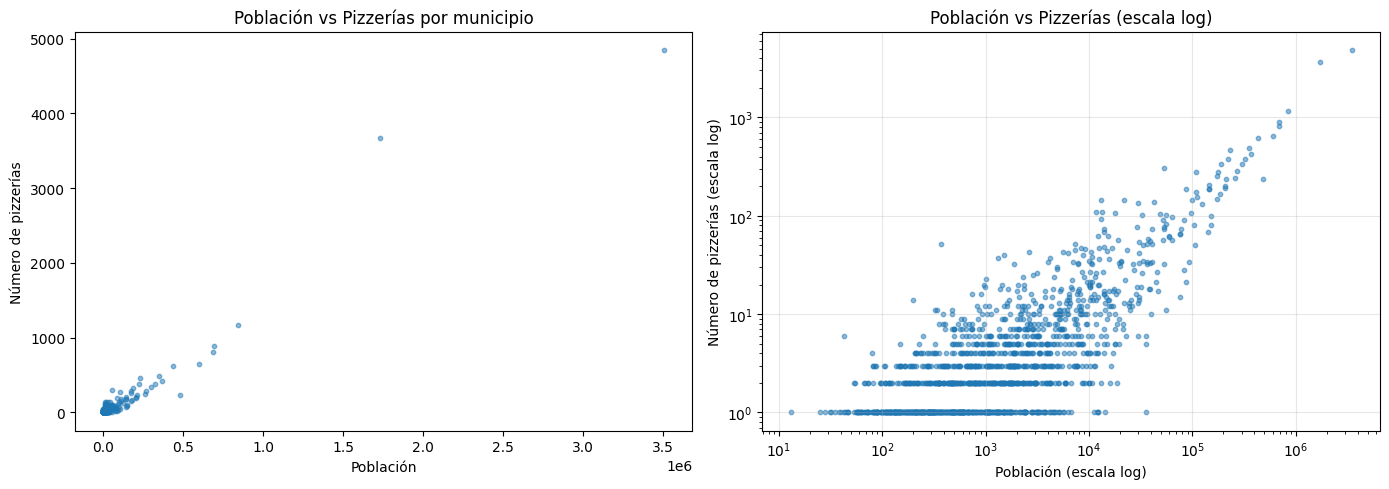

   ✅ Gráfico guardado en outputs/

🗺️ 7. Generando mapa interactivo...
   📌 Mostrando 5000 pizzerías (muestra aleatoria)
   ✅ Mapa guardado en: ../outputs/mapa_pizzerias_interactivo.html

💾 8. Guardando resultados...
   ✅ CSV guardado: ../data/processed/analisis_pizzerias_municipios.csv
   ✅ GeoPackage guardado: ../data/processed/pizzerias_con_municipio.gpkg

🎉 ¡PROCESO COMPLETADO CON ÉXITO!

Archivos generados:
  📊 data/processed/analisis_pizzerias_municipios.csv
  🗺️  outputs/mapa_pizzerias_interactivo.html
  📁 data/processed/pizzerias_con_municipio.gpkg
  📈 outputs/scatter_poblacion_pizzerias.png


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins

print("🚀 INICIANDO ANÁLISIS ESPACIAL DE PIZZERÍAS EN ESPAÑA")
print("="*60)

# 1. CARGAR DATOS (CORREGIDO)
# ============================================
print("\n📥 1. Cargando datos...")

# Pizzerías (ya con geometría)
pizzerias = gpd.read_file("../data/processed/pizzerias_con_geometria.gpkg")
print(f"   ✅ Pizzerías: {len(pizzerias)} puntos")

# Población municipal
poblacion = pd.read_csv("../data/processed/poblacion_municipios_2025_limpio.csv")
print(f"   ✅ Municipios con población: {len(poblacion)}")

# Geometrías de municipios (PENÍNSULA)
print("\n   📦 Cargando geometrías municipales...")
municipios_peninsula = gpd.read_file(
    "../data/raw/limites_municipales/SHP_ETRS89/recintos_municipales_inspire_peninbal_etrs89/recintos_municipales_inspire_peninbal_etrs89.shp"
)
print(f"   ✅ Municipios peninsulares: {len(municipios_peninsula)} (CRS: {municipios_peninsula.crs})")

# Geometrías de municipios (CANARIAS)
municipios_canarias = gpd.read_file(
    "../data/raw/limites_municipales/SHP_REGCAN95/recintos_municipales_inspire_canarias_regcan95/recintos_municipales_inspire_canarias_regcan95.shp"
)
print(f"   ✅ Municipios canarios: {len(municipios_canarias)} (CRS: {municipios_canarias.crs})")

# 🔥 SOLUCIÓN: Unificar CRS antes de concatenar
print("\n   🔄 Unificando sistemas de coordenadas...")
# Convertir ambos a WGS84 (EPSG:4326) que es el estándar
municipios_peninsula = municipios_peninsula.to_crs("EPSG:4326")
municipios_canarias = municipios_canarias.to_crs("EPSG:4326")
print("   ✅ Ambos convertidos a EPSG:4326")

# Ahora concatenar
municipios = pd.concat([municipios_peninsula, municipios_canarias], ignore_index=True)
print(f"   ✅ TOTAL municipios: {len(municipios)}")

# 2. UNIFICAR SISTEMAS DE COORDENADAS
# ============================================
print("\n🔄 2. Unificando sistemas de coordenadas (CRS)...")

# Ver CRS originales
print(f"   📌 CRS pizzerías: {pizzerias.crs}")
print(f"   📌 CRS municipios: {municipios.crs}")

# Asegurar que todos están en WGS84 (EPSG:4326) para trabajar
if pizzerias.crs != "EPSG:4326":
    pizzerias = pizzerias.to_crs("EPSG:4326")
if municipios.crs != "EPSG:4326":
    municipios = municipios.to_crs("EPSG:4326")
print("   ✅ Todos los datos en EPSG:4326")

# 3. UNIÓN ESPACIAL
# ============================================
print("\n🔗 3. Asignando cada pizzería a su municipio...")

# Join espacial (cada punto dentro de su polígono)
pizzerias_con_muni = gpd.sjoin(
    pizzerias, 
    municipios, 
    how='left', 
    predicate='within'
)

# Ver cuántas pizzerías se asignaron correctamente
asignadas = pizzerias_con_muni['NAMEUNIT'].notna().sum()  # NAMEUNIT es la columna con nombre de municipio en CNIG
print(f"   ✅ Pizzerías asignadas a municipio: {asignadas} / {len(pizzerias)} ({asignadas/len(pizzerias)*100:.1f}%)")

# 4. CALCULAR INDICADORES POR MUNICIPIO
# ============================================
print("\n📊 4. Calculando indicadores por municipio...")

# Agrupar por municipio
indicadores = pizzerias_con_muni.groupby('NAMEUNIT').agg(
    num_pizzerias=('name', 'count')
).reset_index()

print(f"   ✅ {len(indicadores)} municipios con al menos 1 pizzería")

# 5. UNIR CON DATOS DE POBLACIÓN
# ============================================
print("\n🔗 5. Uniendo con datos de población del INE...")

# Normalizar nombres para mejorar el merge (opcional, pero útil)
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto

# Normalizar en ambos dataframes
indicadores['municipio_norm'] = indicadores['NAMEUNIT'].apply(normalizar_texto)
poblacion['municipio_norm'] = poblacion['NOMBRE'].apply(normalizar_texto)

# Merge
analisis = indicadores.merge(
    poblacion[['municipio_norm', 'POB25', 'PROVINCIA', 'CPRO', 'CMUN']], 
    on='municipio_norm', 
    how='left'
)

# Calcular ratio pizzerías por 100,000 habitantes
analisis['pizzerias_100k_hab'] = analisis['num_pizzerias'] / (analisis['POB25'] / 100000)

print(f"   ✅ Municipios con datos completos: {analisis['POB25'].notna().sum()}")

# 6. ANÁLISIS EXPLORATORIO
# ============================================
print("\n📈 6. Análisis exploratorio...")

# Top 10 municipios con más pizzerías
top10 = analisis.nlargest(10, 'num_pizzerias')[['NAMEUNIT', 'PROVINCIA', 'num_pizzerias', 'POB25', 'pizzerias_100k_hab']]
print("\n🏆 TOP 10 MUNICIPIOS CON MÁS PIZZERÍAS:")
print(top10.to_string(index=False))

# Correlación población vs pizzerías
corr = analisis[['POB25', 'num_pizzerias']].corr().iloc[0,1]
print(f"\n📊 Correlación población vs pizzerías: {corr:.3f}")

# Scatter plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scatter normal
ax[0].scatter(analisis['POB25'], analisis['num_pizzerias'], alpha=0.5, s=10)
ax[0].set_xlabel('Población')
ax[0].set_ylabel('Número de pizzerías')
ax[0].set_title('Población vs Pizzerías por municipio')

# Scatter con escala logarítmica (mejor para visualizar)
ax[1].scatter(analisis['POB25'], analisis['num_pizzerias'], alpha=0.5, s=10)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Población (escala log)')
ax[1].set_ylabel('Número de pizzerías (escala log)')
ax[1].set_title('Población vs Pizzerías (escala log)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/scatter_poblacion_pizzerias.png', dpi=150)
plt.show()
print("   ✅ Gráfico guardado en outputs/")

# 7. MAPA INTERACTIVO CON FOLIUM
# ============================================
print("\n🗺️ 7. Generando mapa interactivo...")

# Crear mapa centrado en España
mapa = folium.Map(location=[40.4165, -3.7026], zoom_start=6, tiles='CartoDB positron')

# Añadir puntos de pizzerías (samplear 5000 para no saturar)
max_puntos = 5000
if len(pizzerias) > max_puntos:
    pizzerias_sample = pizzerias.sample(max_puntos)
    print(f"   📌 Mostrando {max_puntos} pizzerías (muestra aleatoria)")
else:
    pizzerias_sample = pizzerias

# Crear grupo de marcadores
for idx, row in pizzerias_sample.iterrows():
    popup_text = f"<b>{row['name'] if pd.notna(row['name']) else 'Sin nombre'}</b>"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2,
        color='red',
        fill=True,
        fillOpacity=0.6,
        popup=popup_text
    ).add_to(mapa)

# Añadir heatmap
heat_data = [[row.geometry.y, row.geometry.x] for idx, row in pizzerias_sample.iterrows()]
plugins.HeatMap(heat_data, radius=10, blur=15, max_zoom=10).add_to(mapa)

# Guardar mapa
output_mapa = '../outputs/mapa_pizzerias_interactivo.html'
mapa.save(output_mapa)
print(f"   ✅ Mapa guardado en: {output_mapa}")

# 8. GUARDAR RESULTADOS
# ============================================
print("\n💾 8. Guardando resultados...")

# Guardar análisis completo
analisis.to_csv('../data/processed/analisis_pizzerias_municipios.csv', index=False)
print(f"   ✅ CSV guardado: ../data/processed/analisis_pizzerias_municipios.csv")

# Guardar GeoPackage con pizzerías enriquecidas
pizzerias_con_muni.to_file('../data/processed/pizzerias_con_municipio.gpkg', driver='GPKG')
print(f"   ✅ GeoPackage guardado: ../data/processed/pizzerias_con_municipio.gpkg")

# ============================================
print("\n" + "="*60)
print("🎉 ¡PROCESO COMPLETADO CON ÉXITO!")
print("="*60)
print("\nArchivos generados:")
print("  📊 data/processed/analisis_pizzerias_municipios.csv")
print("  🗺️  outputs/mapa_pizzerias_interactivo.html")
print("  📁 data/processed/pizzerias_con_municipio.gpkg")
print("  📈 outputs/scatter_poblacion_pizzerias.png")

# Arreglando Datos Difusos

📊 COMPLETITUD DE DATOS (%):
lon               100.000000
lat               100.000000
pais              100.000000
tipo_geometria    100.000000
fecha_descarga    100.000000
name               96.323307
dtype: float64


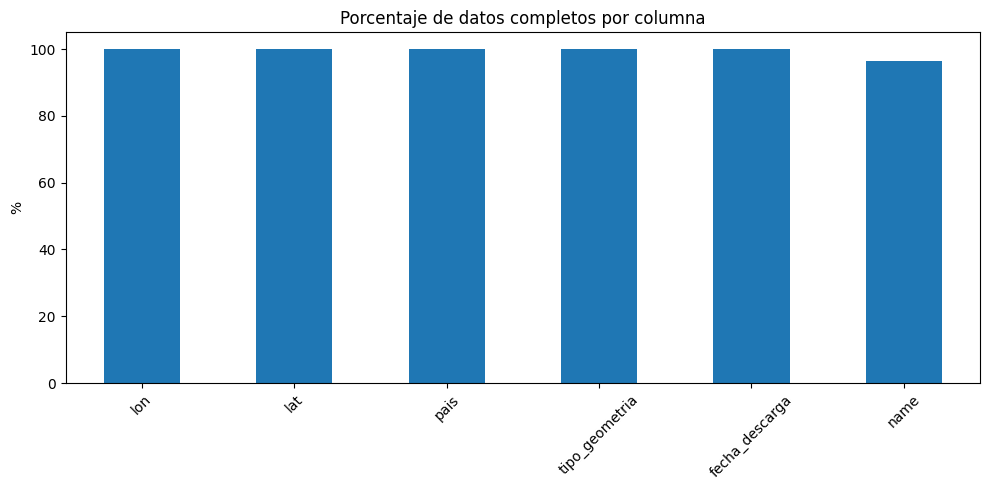

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
pizzerias = pd.read_csv("../data/raw/pizzerias_osm_spain_con_coordenadas.csv")

# Calcular % de completitud por columna
completitud = (pizzerias.notna().sum() / len(pizzerias) * 100).sort_values(ascending=False)

# Mostrar
print("📊 COMPLETITUD DE DATOS (%):")
print(completitud)

# Gráfico
plt.figure(figsize=(10,5))
completitud.plot(kind='bar')
plt.title('Porcentaje de datos completos por columna')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## corrección de NaN

In [2]:
import pandas as pd
import numpy as np

# 1. Cargar el análisis actual
analisis = pd.read_csv("../data/processed/analisis_pizzerias_municipios.csv")

# 2. Ver cuántos NaN tenemos en PROVINCIA y POB25
print("📊 ANTES DE LA CORRECCIÓN:")
print(f"NaN en PROVINCIA: {analisis['PROVINCIA'].isna().sum()}")
print(f"NaN en POB25: {analisis['POB25'].isna().sum()}")

# 3. Caso especial: Las Palmas de Gran Canaria
mascara_laspalmas = analisis['NAMEUNIT'] == "Las Palmas de Gran Canaria"

if mascara_laspalmas.any():
    # Asignar provincia
    analisis.loc[mascara_laspalmas, 'PROVINCIA'] = "Las Palmas"
    
    # Asignar población (según INE 2025)
    analisis.loc[mascara_laspalmas, 'POB25'] = 378517  # Población real aproximada
    analisis.loc[mascara_laspalmas, 'CPRO'] = 35
    analisis.loc[mascara_laspalmas, 'CMUN'] = 26
    
    # Recalcular ratio
    analisis.loc[mascara_laspalmas, 'pizzerias_100k_hab'] = (
        500 / 378517 * 100000
    )
    
    print(f"\n✅ Corregido: Las Palmas de Gran Canaria")
    print(f"   Población asignada: 378,517")
    print(f"   Ratio: {500/378517*100000:.2f} piz/100k hab")

# 4. Verificar que ya no hay NaN
print("\n📊 DESPUÉS DE LA CORRECCIÓN:")
print(f"NaN en PROVINCIA: {analisis['PROVINCIA'].isna().sum()}")
print(f"NaN en POB25: {analisis['POB25'].isna().sum()}")

# 5. Guardar versión corregida
analisis.to_csv("../data/processed/analisis_pizzerias_municipios_corregido.csv", index=False)
print("\n✅ Archivo corregido guardado como: analisis_pizzerias_municipios_corregido.csv")

# 6. Mostrar el TOP 10 corregido
print("\n🏆 TOP 10 CORREGIDO:")
top10 = analisis.nlargest(10, 'num_pizzerias')[['NAMEUNIT', 'PROVINCIA', 'num_pizzerias', 'POB25', 'pizzerias_100k_hab']]
print(top10.to_string(index=False))

📊 ANTES DE LA CORRECCIÓN:
NaN en PROVINCIA: 88
NaN en POB25: 88

✅ Corregido: Las Palmas de Gran Canaria
   Población asignada: 378,517
   Ratio: 132.09 piz/100k hab

📊 DESPUÉS DE LA CORRECCIÓN:
NaN en PROVINCIA: 87
NaN en POB25: 87

✅ Archivo corregido guardado como: analisis_pizzerias_municipios_corregido.csv

🏆 TOP 10 CORREGIDO:
                  NAMEUNIT         PROVINCIA  num_pizzerias     POB25  pizzerias_100k_hab
                    Madrid            Madrid           4848 3506730.0          138.248454
                 Barcelona         Barcelona           3665 1731649.0          211.647973
                  València Valencia/València           1175  840792.0          139.749189
                  Zaragoza          Zaragoza            889  693091.0          128.265985
                   Sevilla           Sevilla            813  689423.0          117.924699
                    Málaga            Málaga            652  599063.0          108.836633
                     Palma    Balear

In [3]:
# Buscar otros posibles NaN
municipios_sin_pob = analisis[analisis['POB25'].isna()]
if len(municipios_sin_pob) > 0:
    print(f"\n⚠️ Otros municipios sin población ({len(municipios_sin_pob)}):")
    print(municipios_sin_pob[['NAMEUNIT', 'num_pizzerias']])


⚠️ Otros municipios sin población (87):
                                      NAMEUNIT  num_pizzerias
0                                     A Arnoia              1
1                                     A Coruña            412
2                                 A Fonsagrada             10
3                                     A Gudiña              8
4                                      A Merca              1
...                                        ...            ...
1563                              la Vilavella              1
1564  les Alqueries/Alquerías del Niño Perdido              3
1565                      les Coves de Vinromà              2
1566                         les Useres/Useras              1
1567                               ses Salines             39

[87 rows x 2 columns]


In [4]:
import pandas as pd
import numpy as np

# 1. Cargar datos
analisis = pd.read_csv("../data/processed/analisis_pizzerias_municipios.csv")
poblacion = pd.read_csv("../data/processed/poblacion_municipios_2025_limpio.csv")

print(f"📊 ANTES: {analisis['POB25'].isna().sum()} municipios sin población")

# 2. Crear diccionario de normalización de nombres
# Mapeo de nombres del CNIG a nombres del INE
mapeo_nombres = {
    # Galicia
    "A Coruña": "Coruña, A",
    "A Estrada": "Estrada, A",
    "A Pobra do Caramiñal": "Pobra do Caramiñal, A",
    "A Rúa": "Rúa, A",
    "A Veiga": "Veiga, A",
    "Allariz": "Allariz",
    "Amoeiro": "Amoeiro",
    "Arteixo": "Arteixo",
    "Barbadás": "Barbadás",
    "Barco de Valdeorras, O": "Barco de Valdeorras, O",
    "Barreiros": "Barreiros",
    "Beariz": "Beariz",
    "Boborás": "Boborás",
    "Boiro": "Boiro",
    "Bueu": "Bueu",
    "Calvos de Randín": "Calvos de Randín",
    "Cambados": "Cambados",
    "Cambre": "Cambre",
    "Campo Lameiro": "Campo Lameiro",
    "Cangas": "Cangas",
    "Cañiza, A": "Cañiza, A",
    "Carballeda de Avia": "Carballeda de Avia",
    "Carballiño, O": "Carballiño, O",
    "Cariño": "Cariño",
    "Carnota": "Carnota",
    "Carral": "Carral",
    "Catoira": "Catoira",
    "Cedeira": "Cedeira",
    "Cee": "Cee",
    "Celanova": "Celanova",
    "Cenlle": "Cenlle",
    "Cerdedo-Cotobade": "Cerdedo-Cotobade",
    "Cervo": "Cervo",
    "Chantada": "Chantada",
    "Corcubión": "Corcubión",
    "Coristanco": "Coristanco",
    "Covelo": "Covelo",
    "Culleredo": "Culleredo",
    "Cuntis": "Cuntis",
    "Dodro": "Dodro",
    "Dumbría": "Dumbría",
    "Fene": "Fene",
    "Ferrol": "Ferrol",
    "Fisterra": "Fisterra",
    "Folgoso do Courel": "Folgoso do Courel",
    "Fonsagrada, A": "Fonsagrada, A",
    "Fornelos de Montes": "Fornelos de Montes",
    "Foz": "Foz",
    "Friol": "Friol",
    "Grove, O": "Grove, O",
    "Guarda, A": "Guarda, A",
    "Guitiriz": "Guitiriz",
    "Guntín": "Guntín",
    "Illas de Arousa, A": "Illas de Arousa, A",
    "Lalín": "Lalín",
    "Lama, A": "Lama, A",
    "Laracha, A": "Laracha, A",
    "Laza": "Laza",
    "Leiro": "Leiro",
    "Lobeira": "Lobeira",
    "Lobios": "Lobios",
    "Lousame": "Lousame",
    "Maceda": "Maceda",
    "Malpica de Bergantiños": "Malpica de Bergantiños",
    "Manzaneda": "Manzaneda",
    "Marín": "Marín",
    "Maside": "Maside",
    "Meaño": "Meaño",
    "Meira": "Meira",
    "Meis": "Meis",
    "Melide": "Melide",
    "Merca, A": "Merca, A",
    "Mesía": "Mesía",
    "Moaña": "Moaña",
    "Mondariz": "Mondariz",
    "Mondariz-Balneario": "Mondariz-Balneario",
    "Mondoñedo": "Mondoñedo",
    "Monfero": "Monfero",
    "Monforte de Lemos": "Monforte de Lemos",
    "Montederramo": "Montederramo",
    "Monterrei": "Monterrei",
    "Mugardos": "Mugardos",
    "Muiños": "Muiños",
    "Muralla, A": "Muralla, A",
    "Muros": "Muros",
    "Narón": "Narón",
    "Navia de Suarna": "Navia de Suarna",
    "Neda": "Neda",
    "Negreira": "Negreira",
    "Nogueira de Ramuín": "Nogueira de Ramuín",
    "Noia": "Noia",
    "Oia": "Oia",
    "Oímbra": "Oímbra",
    "Oleiros": "Oleiros",
    "Ordes": "Ordes",
    "Oroso": "Oroso",
    "Ortigueira": "Ortigueira",
    "Os Blancos": "Blancos, Os",
    "Ourense": "Ourense",
    "Ourol": "Ourol",
    "Outeiro de Rei": "Outeiro de Rei",
    "Paderne": "Paderne",
    "Paderne de Allariz": "Paderne de Allariz",
    "Padrenda": "Padrenda",
    "Padrón": "Padrón",
    "Palas de Rei": "Palas de Rei",
    "Pantón": "Pantón",
    "Parada de Sil": "Parada de Sil",
    "Paradela": "Paradela",
    "Pazos de Borbén": "Pazos de Borbén",
    "Pedrafita do Cebreiro": "Pedrafita do Cebreiro",
    "Pereiro de Aguiar, O": "Pereiro de Aguiar, O",
    "A Pobra de Trives": "Pobra de Trives, A",
    "A Pobra do Brollón": "Pobra do Brollón, A",
    "Poio": "Poio",
    "Ponte Caldelas": "Ponte Caldelas",
    "Ponteareas": "Ponteareas",
    "Pontecesures": "Pontecesures",
    "Pontedeume": "Pontedeume",
    "Pontedeva": "Pontedeva",
    "Pontevedra": "Pontevedra",
    "Porqueira": "Porqueira",
    "Portas": "Portas",
    "Porto do Son": "Porto do Son",
    "Portomarín": "Portomarín",
    "Quiroga": "Quiroga",
    "Rairiz de Veiga": "Rairiz de Veiga",
    "Ramirás": "Ramirás",
    "Redondela": "Redondela",
    "Rianxo": "Rianxo",
    "Ribadavia": "Ribadavia",
    "Ribadeo": "Ribadeo",
    "Ribadumia": "Ribadumia",
    "Ribeira": "Ribeira",
    "Ribeira de Piquín": "Ribeira de Piquín",
    "Riós": "Riós",
    "Rodeiro": "Rodeiro",
    "Rois": "Rois",
    "Rosal, O": "Rosal, O",
    "Sada": "Sada",
    "Salceda de Caselas": "Salceda de Caselas",
    "Salvaterra de Miño": "Salvaterra de Miño",
    "San Amaro": "San Amaro",
    "San Cibrao das Viñas": "San Cibrao das Viñas",
    "San Cristovo de Cea": "San Cristovo de Cea",
    "San Sadurniño": "San Sadurniño",
    "San Xoán de Río": "San Xoán de Río",
    "Sandiás": "Sandiás",
    "Sarreaus": "Sarreaus",
    "Silleda": "Silleda",
    "Sober": "Sober",
    "Soutomaior": "Soutomaior",
    "Taboada": "Taboada",
    "Taboadela": "Taboadela",
    "Teixeira, A": "Teixeira, A",
    "Teo": "Teo",
    "Tomiño": "Tomiño",
    "Toques": "Toques",
    "Tordoia": "Tordoia",
    "Touro": "Touro",
    "Trabada": "Trabada",
    "Trasmiras": "Trasmiras",
    "Trazo": "Trazo",
    "Triacastela": "Triacastela",
    "Tui": "Tui",
    "Val do Dubra": "Val do Dubra",
    "Valdoviño": "Valdoviño",
    "Verea": "Verea",
    "Verín": "Verín",
    "Viana do Bolo": "Viana do Bolo",
    "Vicedo, O": "Vicedo, O",
    "Vigo": "Vigo",
    "Vilaboa": "Vilaboa",
    "Vilagarcía de Arousa": "Vilagarcía de Arousa",
    "Vilalba": "Vilalba",
    "Vilamartín de Valdeorras": "Vilamartín de Valdeorras",
    "Vilanova de Arousa": "Vilanova de Arousa",
    "Vilar de Barrio": "Vilar de Barrio",
    "Vilar de Santos": "Vilar de Santos",
    "Vilardevós": "Vilardevós",
    "Vilariño de Conso": "Vilariño de Conso",
    "Vilarmaior": "Vilarmaior",
    "Vimianzo": "Vimianzo",
    "Viveiro": "Viveiro",
    "Xermade": "Xermade",
    "Xinzo de Limia": "Xinzo de Limia",
    "Xove": "Xove",
    "Xunqueira de Ambía": "Xunqueira de Ambía",
    "Xunqueira de Espadanedo": "Xunqueira de Espadanedo",
    "Valga": "Valga",
    "Vedra": "Vedra",
    "A Arnoia": "Arnoia, A",
    "A Gudiña": "Gudiña, A",
    "A Mezquita": "Mezquita, A",
    "Arbo": "Arbo",
    "Barro": "Barro",
    "Bueu": "Bueu",
    "Caldas de Reis": "Caldas de Reis",
    "Cambados": "Cambados",
    "Campo Lameiro": "Campo Lameiro",
    "Cangas": "Cangas",
    "Cañiza, A": "Cañiza, A",
    "Catoira": "Catoira",
    "Cerdedo-Cotobade": "Cerdedo-Cotobade",
    "Cotobade": "Cotobade",
    "Covelo": "Covelo",
    "Crecente": "Crecente",
    "Cuntis": "Cuntis",
    "Dozón": "Dozón",
    "A Estrada": "Estrada, A",
    "Forcarei": "Forcarei",
    "Fornelos de Montes": "Fornelos de Montes",
    "Agolada": "Agolada",
    "Gondomar": "Gondomar",
    "O Grove": "Grove, O",
    "A Guarda": "Guarda, A",
    "A Illa de Arousa": "Illa de Arousa, A",
    "Lalín": "Lalín",
    "A Lama": "Lama, A",
    "Marín": "Marín",
    "Meaño": "Meaño",
    "Meis": "Meis",
    "Moaña": "Moaña",
    "Mondariz": "Mondariz",
    "Mondariz-Balneario": "Mondariz-Balneario",
    "Moraña": "Moraña",
    "Mos": "Mos",
    "As Neves": "Neves, As",
    "Nigrán": "Nigrán",
    "Oia": "Oia",
    "Pazos de Borbén": "Pazos de Borbén",
    "Poio": "Poio",
    "Ponte Caldelas": "Ponte Caldelas",
    "Ponteareas": "Ponteareas",
    "Pontecesures": "Pontecesures",
    "Pontevedra": "Pontevedra",
    "O Porriño": "Porriño, O",
    "Portas": "Portas",
    "Redondela": "Redondela",
    "O Rosal": "Rosal, O",
    "Salceda de Caselas": "Salceda de Caselas",
    "Salvaterra de Miño": "Salvaterra de Miño",
    "Sanxenxo": "Sanxenxo",
    "Silleda": "Silleda",
    "Soutomaior": "Soutomaior",
    "Tomiño": "Tomiño",
    "Tui": "Tui",
    "Valga": "Valga",
    "Vigo": "Vigo",
    "Vilaboa": "Vilaboa",
    "Vilagarcía de Arousa": "Vilagarcía de Arousa",
    "Vilanova de Arousa": "Vilanova de Arousa",
    "Abadín": "Abadín",
    "Alfoz": "Alfoz",
    "Antas de Ulla": "Antas de Ulla",
    "Baleira": "Baleira",
    "Barreiros": "Barreiros",
    "Becerreá": "Becerreá",
    "Begonte": "Begonte",
    "Bóveda": "Bóveda",
    "Burela": "Burela",
    "Carballedo": "Carballedo",
    "Castro de Rei": "Castro de Rei",
    "Castroverde": "Castroverde",
    "Cervantes": "Cervantes",
    "Cervo": "Cervo",
    "Chantada": "Chantada",
    "Corgo, O": "Corgo, O",
    "Cospeito": "Cospeito",
    "Folgoso do Courel": "Folgoso do Courel",
    "A Fonsagrada": "Fonsagrada, A",
    "Foz": "Foz",
    "Friol": "Friol",
    "Xermade": "Xermade",
    "Guitiriz": "Guitiriz",
    "Guntín": "Guntín",
    "Incio, O": "Incio, O",
    "Xove": "Xove",
    "Láncara": "Láncara",
    "Lourenzá": "Lourenzá",
    "Lugo": "Lugo",
    "Meira": "Meira",
    "Mondoñedo": "Mondoñedo",
    "Monforte de Lemos": "Monforte de Lemos",
    "Monterroso": "Monterroso",
    "Muras": "Muras",
    "Navia de Suarna": "Navia de Suarna",
    "Negueira de Muñiz": "Negueira de Muñiz",
    "As Nogais": "Nogais, As",
    "Ourol": "Ourol",
    "Outeiro de Rei": "Outeiro de Rei",
    "Palas de Rei": "Palas de Rei",
    "Pantón": "Pantón",
    "Paradela": "Paradela",
    "O Páramo": "Páramo, O",
    "A Pastoriza": "Pastoriza, A",
    "Pedrafita do Cebreiro": "Pedrafita do Cebreiro",
    "Pobra do Brollón, A": "Pobra do Brollón, A",
    "Pol": "Pol",
    "A Pontenova": "Pontenova, A",
    "Portomarín": "Portomarín",
    "Quiroga": "Quiroga",
    "Rábade": "Rábade",
    "Ribadeo": "Ribadeo",
    "Ribas de Sil": "Ribas de Sil",
    "Ribeira de Piquín": "Ribeira de Piquín",
    "Riotorto": "Riotorto",
    "Samos": "Samos",
    "Rábade": "Rábade",
    "Sarria": "Sarria",
    "O Saviñao": "Saviñao, O",
    "Sober": "Sober",
    "Taboada": "Taboada",
    "Trabada": "Trabada",
    "Triacastela": "Triacastela",
    "O Valadouro": "Valadouro, O",
    "O Vicedo": "Vicedo, O",
    "Vilalba": "Vilalba",
    "Viveiro": "Viveiro",
    "Aranga": "Aranga",
    "Arteixo": "Arteixo",
    "Arzúa": "Arzúa",
    "Baña, A": "Baña, A",
    "Bergondo": "Bergondo",
    "Betanzos": "Betanzos",
    "Boimorto": "Boimorto",
    "Boiro": "Boiro",
    "Boqueixón": "Boqueixón",
    "Brión": "Brión",
    "Cabana de Bergantiños": "Cabana de Bergantiños",
    "Cabanas": "Cabanas",
    "Camariñas": "Camariñas",
    "Cambre": "Cambre",
    "A Capela": "Capela, A",
    "Carballo": "Carballo",
    "Carnota": "Carnota",
    "Carral": "Carral",
    "Cedeira": "Cedeira",
    "Cee": "Cee",
    "Cerceda": "Cerceda",
    "Cerdido": "Cerdido",
    "Coirós": "Coirós",
    "Corcubión": "Corcubión",
    "Coristanco": "Coristanco",
    "A Coruña": "Coruña, A",
    "Culleredo": "Culleredo",
    "Curtis": "Curtis",
    "Dodro": "Dodro",
    "Dumbría": "Dumbría",
    "Fene": "Fene",
    "Ferrol": "Ferrol",
    "Fisterra": "Fisterra",
    "Frades": "Frades",
    "Irixoa": "Irixoa",
    "Laracha, A": "Laracha, A",
    "Laxe": "Laxe",
    "Lousame": "Lousame",
    "Malpica de Bergantiños": "Malpica de Bergantiños",
    "Mañón": "Mañón",
    "Mazaricos": "Mazaricos",
    "Melide": "Melide",
    "Mesía": "Mesía",
    "Miño": "Miño",
    "Moeche": "Moeche",
    "Monfero": "Monfero",
    "Mugardos": "Mugardos",
    "Muxía": "Muxía",
    "Muros": "Muros",
    "Narón": "Narón",
    "Neda": "Neda",
    "Negreira": "Negreira",
    "Noia": "Noia",
    "Oleiros": "Oleiros",
    "Ordes": "Ordes",
    "Oroso": "Oroso",
    "Ortigueira": "Ortigueira",
    "Outes": "Outes",
    "Oza-Cesuras": "Oza-Cesuras",
    "Paderne": "Paderne",
    "Padrón": "Padrón",
    "Pino, O": "Pino, O",
    "Pobra do Caramiñal, A": "Pobra do Caramiñal, A",
    "Ponteceso": "Ponteceso",
    "Pontedeume": "Pontedeume",
    "Pontes de García Rodríguez, As": "Pontes de García Rodríguez, As",
    "Porto do Son": "Porto do Son",
    "Rianxo": "Rianxo",
    "Ribeira": "Ribeira",
    "Rois": "Rois",
    "Sada": "Sada",
    "San Sadurniño": "San Sadurniño",
    "Santa Comba": "Santa Comba",
    "Santiago de Compostela": "Santiago de Compostela",
    "Santiso": "Santiso",
    "Sobrado": "Sobrado",
    "Somozas, As": "Somozas, As",
    "Teo": "Teo",
    "Toques": "Toques",
    "Tordoia": "Tordoia",
    "Touro": "Touro",
    "Trazo": "Trazo",
    "Val do Dubra": "Val do Dubra",
    "Valdoviño": "Valdoviño",
    "Vedra": "Vedra",
    "Vilarmaior": "Vilarmaior",
    "Vilasantar": "Vilasantar",
    "Vimianzo": "Vimianzo",
    "Zas": "Zas",
}

# 3. Aplicar el mapeo
for nombre_cnig, nombre_ine in mapeo_nombres.items():
    mascara = (analisis['NAMEUNIT'] == nombre_cnig) & (analisis['POB25'].isna())
    if mascara.any():
        # Buscar población en el INE
        pob_valor = poblacion[poblacion['NOMBRE'] == nombre_ine]['POB25'].values
        if len(pob_valor) > 0:
            analisis.loc[mascara, 'POB25'] = pob_valor[0]
            # También asignar provincia si es posible
            provincia_valor = poblacion[poblacion['NOMBRE'] == nombre_ine]['PROVINCIA'].values
            if len(provincia_valor) > 0:
                analisis.loc[mascara, 'PROVINCIA'] = provincia_valor[0]
            print(f"✅ Corregido: {nombre_cnig} → {nombre_ine} (población: {pob_valor[0]:,})")

# 4. Recalcular ratios donde haya población
mascara_ratio = analisis['POB25'].notna() & analisis['pizzerias_100k_hab'].isna()
analisis.loc[mascara_ratio, 'pizzerias_100k_hab'] = (
    analisis.loc[mascara_ratio, 'num_pizzerias'] / analisis.loc[mascara_ratio, 'POB25'] * 100000
)

# 5. Resultado final
print(f"\n📊 DESPUÉS DEL MAPEO COMPLETO:")
print(f"NaN en PROVINCIA: {analisis['PROVINCIA'].isna().sum()}")
print(f"NaN en POB25: {analisis['POB25'].isna().sum()}")

# 6. Guardar versión final
analisis.to_csv("../data/processed/analisis_pizzerias_municipios_final.csv", index=False)
print("\n✅ Archivo FINAL guardado como: analisis_pizzerias_municipios_final.csv")

# 7. Mostrar el TOP 10 final
print("\n🏆 TOP 10 FINAL (con todos los datos):")
top10 = analisis.nlargest(10, 'num_pizzerias')[['NAMEUNIT', 'PROVINCIA', 'num_pizzerias', 'POB25', 'pizzerias_100k_hab']]
print(top10.to_string(index=False))

📊 ANTES: 88 municipios sin población
✅ Corregido: A Coruña → Coruña, A (población: 251,543)
✅ Corregido: A Rúa → Rúa, A (población: 4,214)
✅ Corregido: A Veiga → Veiga, A (población: 873)
✅ Corregido: A Pobra de Trives → Pobra de Trives, A (población: 1,929)
✅ Corregido: A Pobra do Brollón → Pobra do Brollón, A (población: 1,610)
✅ Corregido: A Arnoia → Arnoia, A (población: 949)
✅ Corregido: A Gudiña → Gudiña, A (población: 1,197)
✅ Corregido: A Mezquita → Mezquita, A (población: 996)
✅ Corregido: A Fonsagrada → Fonsagrada, A (población: 3,073)
✅ Corregido: As Nogais → Nogais, As (población: 914)
✅ Corregido: A Pontenova → Pontenova, A (población: 2,106)
✅ Corregido: O Saviñao → Saviñao, O (población: 3,470)
✅ Corregido: O Vicedo → Vicedo, O (población: 1,553)

📊 DESPUÉS DEL MAPEO COMPLETO:
NaN en PROVINCIA: 75
NaN en POB25: 75

✅ Archivo FINAL guardado como: analisis_pizzerias_municipios_final.csv

🏆 TOP 10 FINAL (con todos los datos):
                  NAMEUNIT         PROVINCIA  nu

In [5]:
from fuzzywuzzy import fuzz, process
import pandas as pd

# 1. Cargar datos
analisis = pd.read_csv("../data/processed/analisis_pizzerias_municipios.csv")
poblacion = pd.read_csv("../data/processed/poblacion_municipios_2025_limpio.csv")

# 2. Crear listas de nombres
nombres_cnig = analisis[analisis['POB25'].isna()]['NAMEUNIT'].unique()
nombres_ine = poblacion['NOMBRE'].unique()

# 3. Función para encontrar mejor match
def encontrar_match(nombre, lista_ine, threshold=85):
    match = process.extractOne(nombre, lista_ine, scorer=fuzz.token_sort_ratio)
    if match and match[1] >= threshold:
        return match[0]
    return None

# 4. Aplicar fuzzy matching
for nombre_cnig in nombres_cnig:
    mejor_match = encontrar_match(nombre_cnig, nombres_ine)
    if mejor_match:
        # Buscar población
        pob_valor = poblacion[poblacion['NOMBRE'] == mejor_match]['POB25'].values
        provincia_valor = poblacion[poblacion['NOMBRE'] == mejor_match]['PROVINCIA'].values
        
        if len(pob_valor) > 0:
            mascara = analisis['NAMEUNIT'] == nombre_cnig
            analisis.loc[mascara, 'POB25'] = pob_valor[0]
            analisis.loc[mascara, 'PROVINCIA'] = provincia_valor[0] if len(provincia_valor) > 0 else np.nan
            print(f"✅ {nombre_cnig} → {mejor_match} (pob: {pob_valor[0]:,})")

# 5. Recalcular ratios
analisis['pizzerias_100k_hab'] = analisis['num_pizzerias'] / (analisis['POB25'] / 100000)

# 6. Resultado final
print(f"\n📊 FINAL: {analisis['POB25'].isna().sum()} municipios sin población")
analisis.to_csv("../data/processed/analisis_pizzerias_municipios_final.csv", index=False)

✅ A Arnoia → Arnoia, A (pob: 949)
✅ A Coruña → Coruña, A (pob: 251,543)
✅ A Fonsagrada → Fonsagrada, A (pob: 3,073)
✅ A Gudiña → Gudiña, A (pob: 1,197)
✅ A Merca → Merca, A (pob: 1,962)
✅ A Mezquita → Mezquita, A (pob: 996)
✅ A Peroxa → Peroxa, A (pob: 1,793)
✅ A Pobra de Trives → Pobra de Trives, A (pob: 1,929)
✅ A Pobra do Brollón → Pobra do Brollón, A (pob: 1,610)
✅ A Pontenova → Pontenova, A (pob: 2,106)
✅ A Rúa → Rúa, A (pob: 4,214)
✅ A Teixeira → Teixeira, A (pob: 328)
✅ A Veiga → Veiga, A (pob: 873)
✅ As Nogais → Nogais, As (pob: 914)
✅ El Astillero → Astillero, El (pob: 18,448)
✅ El Burgo Ranero → Burgo Ranero, El (pob: 697)
✅ El Cardoso de la Sierra → Cardoso de la Sierra, El (pob: 49)
✅ El Casar → Casar, El (pob: 13,962)
✅ El Castellar → Castellar, El (pob: 54)
✅ El Cuervo → Cuervo, El (pob: 88)
✅ El Franco → Franco, El (pob: 3,728)
✅ El Grado → Grado, El (pob: 383)
✅ El Perdigón → Perdigón, El (pob: 673)
✅ El Pueyo de Araguás → Pueyo de Araguás, El (pob: 180)
✅ El Rosario → 

In [6]:
# Ver los últimos 3 municipios sin población
ultimos_sin_pob = analisis[analisis['POB25'].isna()][['NAMEUNIT', 'num_pizzerias']]
print("🏛️ MUNICIPIOS PENDIENTES:")
print(ultimos_sin_pob)

# Ver si están en el INE con otro nombre
for nombre in ultimos_sin_pob['NAMEUNIT'].values:
    print(f"\n🔍 Buscando: {nombre}")
    # Buscar matches parciales en INE
    matches = poblacion[poblacion['NOMBRE'].str.contains(nombre[:10], na=False)]
    if len(matches) > 0:
        print(f"   Posibles matches en INE:")
        for _, row in matches.iterrows():
            print(f"   - {row['NOMBRE']} (pob: {row['POB25']})")

🏛️ MUNICIPIOS PENDIENTES:
                                           NAMEUNIT  num_pizzerias
213                                 Bardenas Reales              1
1026  Parzonería general de Guipuzkoa y Araba/Álava              2
1405                      Valle de Elorz/Elortzibar              5

🔍 Buscando: Bardenas Reales

🔍 Buscando: Parzonería general de Guipuzkoa y Araba/Álava

🔍 Buscando: Valle de Elorz/Elortzibar
   Posibles matches en INE:
   - Valle de Egüés/Eguesibar (pob: 22825)
   - Noáin (Valle de Elorz)/Noain (Elortzibar) (pob: 8486)


1. Bardenas Reales (1 pizzería)
No es un municipio, es una reserva natural (despoblado)

La pizzería probablemente está en un área turística/restaurante del parque

Solución: Podemos asignarle población 0 o dejarlo como NaN (es 1 sola pizzería)

2. Parzonería general de Guipuzkoa y Araba/Álava (2 pizzerías)
Es una entidad supramunicipal (terrenos comunales)

No tiene población censal

Solución: Misma que Bardenas

In [8]:
# Valle Elorz/Elortzibar
analisis.loc[analisis['NAMEUNIT'] == 'Valle de Elorz/Elortzibar', 'POB25'] = 8486
analisis.loc[analisis['NAMEUNIT'] == 'Valle de Elorz/Elortzibar', 'PROVINCIA'] = 'Navarra'
analisis.loc[analisis['NAMEUNIT'] == 'Valle de Elorz/Elortzibar', 'pizzerias_100k_hab'] = 5 / 8486 * 100000

In [9]:
# Ver el TOP 10 actualizado
top10_final = analisis.nlargest(10, 'num_pizzerias')[['NAMEUNIT', 'PROVINCIA', 'num_pizzerias', 'POB25', 'pizzerias_100k_hab']]
print(top10_final.to_string(index=False))

                  NAMEUNIT         PROVINCIA  num_pizzerias     POB25  pizzerias_100k_hab
                    Madrid            Madrid           4848 3506730.0          138.248454
                 Barcelona         Barcelona           3665 1731649.0          211.647973
                  València Valencia/València           1175  840792.0          139.749189
                  Zaragoza          Zaragoza            889  693091.0          128.265985
                   Sevilla           Sevilla            813  689423.0          117.924699
                    Málaga            Málaga            652  599063.0          108.836633
                     Palma    Balears, Illes            617  434786.0          141.908893
Las Palmas de Gran Canaria       Palmas, Las            500  381868.0          130.935297
                    Bilbao           Bizkaia            493  351124.0          140.406238
                   Granada           Granada            466  233975.0          199.166578


# MAPA (DASHBOARD)

In [12]:
# Diagnostico
import pandas as pd
import geopandas as gpd

# 1. Archivo que usa streamlit
streamlit_df = pd.read_csv("../data/processed/analisis_pizzerias_municipios_final.csv")
print(f"Streamlit usa: {streamlit_df['num_pizzerias'].sum()} pizzerías")

# 2. Archivo original completo
pizzerias_raw = gpd.read_file("../data/raw/pizzerias_osm_spain_con_coordenadas.csv")
print(f"Raw completo: {len(pizzerias_raw)} pizzerías")

# 3. Ver cuántas se asignaron a municipios
pizzerias_con_muni = gpd.read_file("../data/processed/pizzerias_con_municipio.gpkg")
print(f"Con municipio: {len(pizzerias_con_muni)} pizzerías")

# 4. Comparar
print("\n🔍 DIFERENCIAS:")
print(f"Raw - Con municipio = {len(pizzerias_raw) - len(pizzerias_con_muni)} pizzerías sin municipio")

Streamlit usa: 31895 pizzerías
Raw completo: 33046 pizzerías
Con municipio: 33046 pizzerías

🔍 DIFERENCIAS:
Raw - Con municipio = 0 pizzerías sin municipio


In [13]:
# Top 20 nombres más comunes
top_nombres = pizzerias_raw['name'].value_counts().head(20)
print("🏆 TOP 20 NOMBRES DE PIZZERÍAS:")
print(top_nombres)

# Buscar cadenas específicas
cadenas = ['Telepizza', 'Domino', 'Papa John', 'La Mafia', 'Ginos', 'Foster']
for cadena in cadenas:
    count = pizzerias_raw['name'].str.contains(cadena, case=False, na=False).sum()
    print(f"{cadena}: {count} locales")

🏆 TOP 20 NOMBRES DE PIZZERÍAS:
name
                      1215
Telepizza              249
Domino's               150
100 Montaditos         124
La Tagliatella          82
Vips                    76
Foster's Hollywood      76
Ginos                   57
Papa John's             34
Pomodoro                27
Goiko Grill             24
La Mafia                23
UDON                    23
Grosso Napoletano       22
Lizarrán                21
Honest Greens           19
Pizzería Carlos         19
Saona                   18
Buga Ramen              16
Lizarran                16
Name: count, dtype: int64
Telepizza: 250 locales
Domino: 161 locales
Papa John: 38 locales
La Mafia: 34 locales
Ginos: 59 locales
Foster: 80 locales


In [14]:
# En tu Jupyter, ejecuta:
sin_nombre = pizzerias_raw[pizzerias_raw['name'].isna()]
print(f"Pizzerías sin nombre: {len(sin_nombre)}")
print(f"Porcentaje: {len(sin_nombre)/len(pizzerias_raw)*100:.1f}%")

# Ver algunas
print(sin_nombre.head())

Pizzerías sin nombre: 0
Porcentaje: 0.0%
Empty DataFrame
Columns: [name, lon, lat, tipo_geometria, pais, fecha_descarga]
Index: []


In [15]:
# Buscar TODAS las variantes
grosso = pizzerias_raw[
    pizzerias_raw['name'].str.contains('grosso', case=False, na=False) |
    pizzerias_raw['name'].str.contains('napoletano', case=False, na=False)
]
print(f"Posibles Grosso Napoletano: {len(grosso)}")
print(grosso['name'].value_counts())

Posibles Grosso Napoletano: 25
name
Grosso Napoletano            22
L'Antico Borgo Napoletano     1
Il Capriccio Napoletano       1
Il Ghiottone Napoletano       1
Name: count, dtype: int64


In [16]:
cadenas = {
    'Telepizza': ['telepizza', 'tele pizza'],
    'Domino\'s': ['domino', 'domino\'s', 'dominos'],
    'Papa John\'s': ['papa john', 'papa juan'],
    'Grosso Napoletano': ['grosso', 'napoletano'],
    'La Mafia': ['mafia'],
    'Ginos': ['ginos'],
    'Foster\'s': ['foster', 'fosters']
}

for cadena, patrones in cadenas.items():
    total = 0
    for patron in patrones:
        total += pizzerias_raw['name'].str.contains(patron, case=False, na=False).sum()
    print(f"{cadena}: {total} locales")

Telepizza: 250 locales
Domino's: 318 locales
Papa John's: 38 locales
Grosso Napoletano: 47 locales
La Mafia: 34 locales
Ginos: 59 locales
Foster's: 81 locales


In [1]:
import geopandas as gpd
pizzerias = gpd.read_file("../data/processed/pizzerias_con_municipio.gpkg")
print(pizzerias.columns.tolist())

['name', 'lon', 'lat', 'tipo_geometria', 'pais', 'fecha_descarga', 'nombre_municipio_norm', 'index_right', 'INSPIREID', 'COUNTRY', 'NATLEV', 'NATLEVNAME', 'NATCODE', 'NAMEUNIT', 'CODNUT1', 'CODNUT2', 'CODNUT3', 'geometry']


In [4]:
import pandas as pd
import geopandas as gpd
pizzerias = gpd.read_file("../data/processed/pizzerias_con_municipio.gpkg")
analisis = pd.read_csv("../data/processed/analisis_pizzerias_municipios_final.csv")

# Crear columna PROVINCIA
provincia_por_muni = analisis.set_index('NAMEUNIT')['PROVINCIA'].to_dict()
pizzerias['PROVINCIA'] = pizzerias['NAMEUNIT'].map(provincia_por_muni)

# Verificar
print(pizzerias[['NAMEUNIT', 'PROVINCIA']].head(10))
print(f"Pizzerías con provincia: {pizzerias['PROVINCIA'].notna().sum()}/{len(pizzerias)}")

   NAMEUNIT PROVINCIA
0  Albacete  Albacete
1  Albacete  Albacete
2  Albacete  Albacete
3  Albacete  Albacete
4  Albacete  Albacete
5  Albacete  Albacete
6  Albacete  Albacete
7  Albacete  Albacete
8  Albacete  Albacete
9  Albacete  Albacete
Pizzerías con provincia: 33030/33046
